In [ ]:
## Linear regression
# Assumptions: linearity, independence, homoscedasticity, and normality of residuals

#### Linear Regression: Simple, multiple, assumptions, diagnostics
#### Regularization: Ridge, Lasso, Elastic Net
#### Polynomial Regression: Feature interactions, overfitting
#### Evaluation Metrics: MSE, RMSE, MAE, R²

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
# from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
# from statsmodels.stats.diagnostic import normal_ad
# from statsmodels.stats.stattools import durbin_watson
# from scipy import stats
# from scipy.special import inv_boxcox

In [2]:
insurancedf = pd.read_csv('insurance.csv')
insurancedf.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurancedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
insurancedf.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


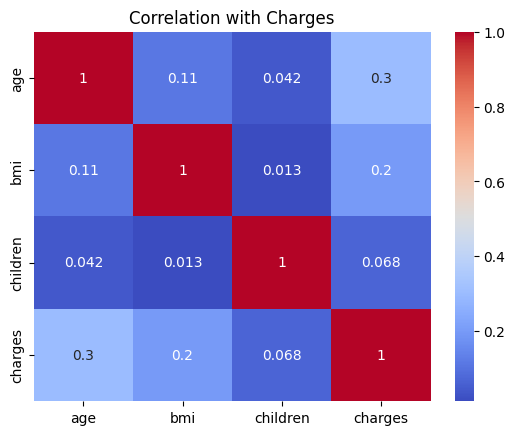

In [5]:
sns.heatmap(insurancedf.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation with Charges")
plt.show()

There is no correlation between any of the variables

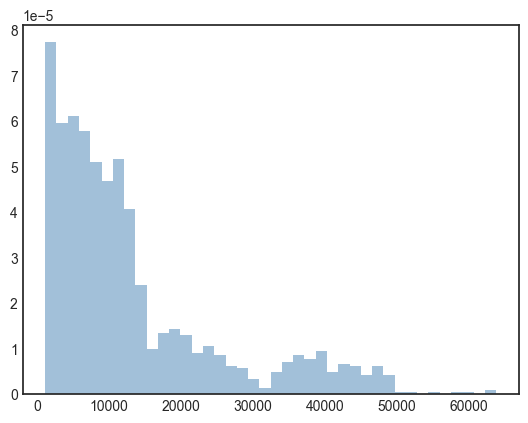

In [6]:
plt.style.use('seaborn-v0_8-white')
# hdata = np.random.randn(1000)
plt.hist(insurancedf["charges"], bins=40, density=True, alpha=0.5, histtype='stepfilled', color='steelblue',
         edgecolor='none');

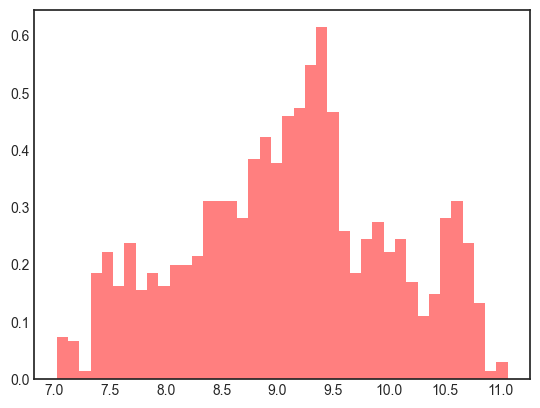

In [7]:
# We will have to use the log for the column due to the skewness of the natural data
plt.hist(np.log(insurancedf["charges"]), bins=40, density=True, alpha=0.5, histtype='stepfilled', color='red',
         edgecolor='none');

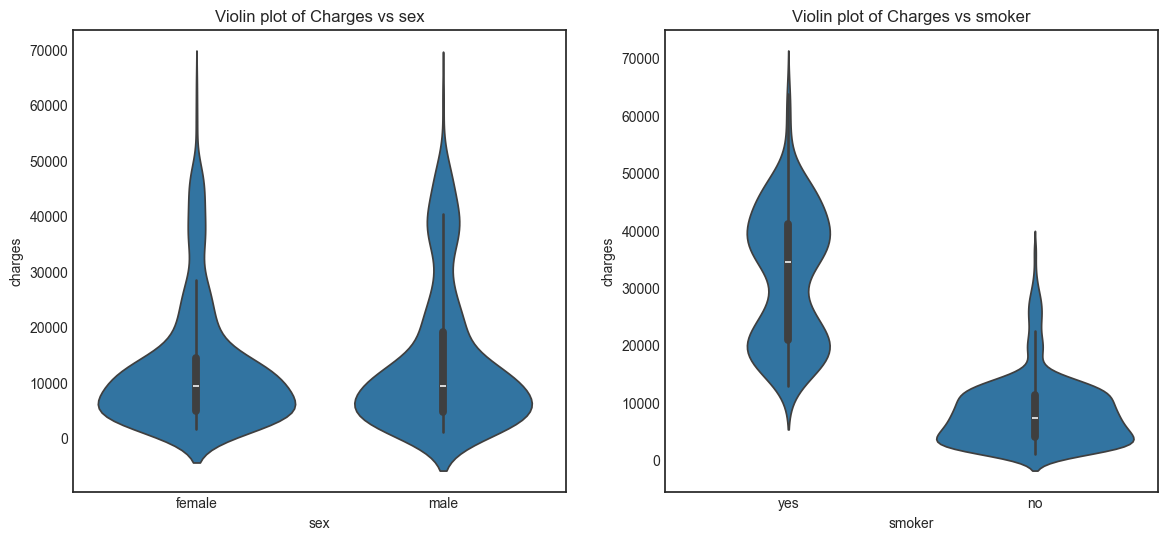

In [8]:
# Violin plot of charges vs sex and charges vs smoker
# Omo, people wey no dey smoke broke oo

f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.violinplot(x='sex', y='charges', data=insurancedf, ax=ax)
ax.set_title('Violin plot of Charges vs sex')

ax = f.add_subplot(122)
sns.violinplot(x='smoker', y='charges',data=insurancedf,ax=ax)
ax.set_title('Violin plot of Charges vs smoker');

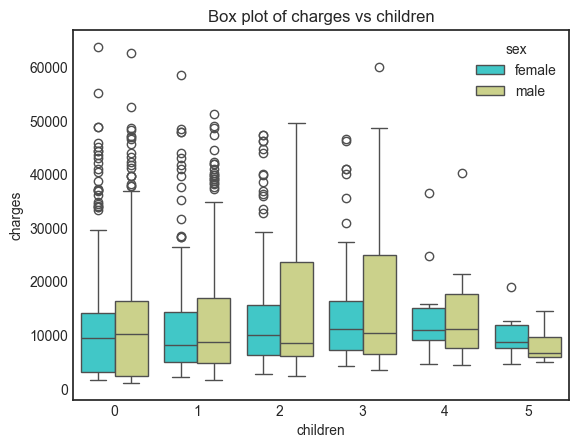

In [9]:
# Boxplot of charges against number of children
# plt.figure(figsize=(14,6))
sns.boxplot(x='children', y='charges', hue='sex', data=insurancedf, palette='rainbow')
plt.title('Box plot of charges vs children');

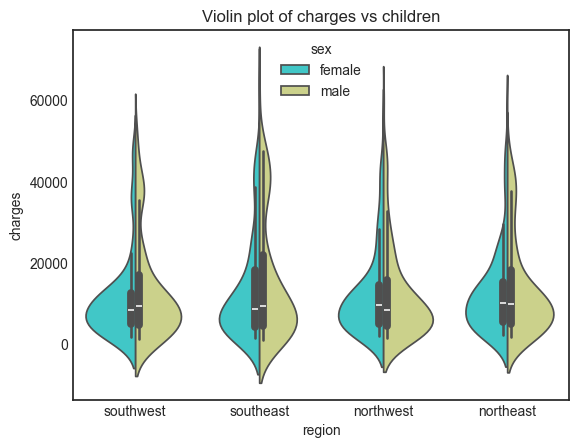

In [10]:
# Boxplot of charges vs region, based on sex
# plt.figure(figsize=(14,6))
sns.violinplot(x='region', y='charges', hue='sex', data=insurancedf, palette='rainbow', split=True)
plt.title('Violin plot of charges vs children');

Text(0.5, 1.0, 'Scatter plot of Charges vs bmi')

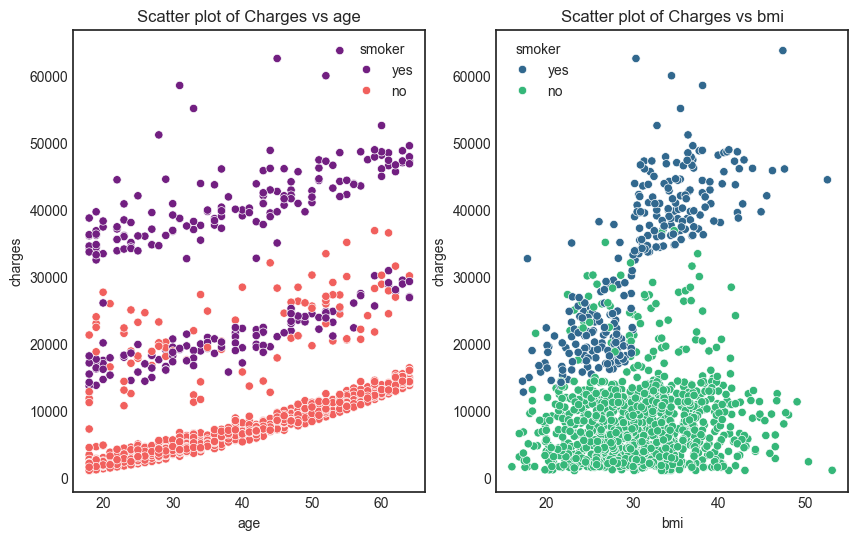

In [11]:
# scatterplot charges vs age and charges vs bmi
f = plt.figure(figsize=(10,6))
ax = f.add_subplot(121)
sns.scatterplot(x='age', y='charges', data=insurancedf, palette='magma', hue= "smoker", ax=ax)
ax.set_title('Scatter plot of Charges vs age')

ax = f.add_subplot(122)
sns.scatterplot(x='bmi', y='charges', data=insurancedf, palette='viridis', hue= "smoker")
ax.set_title('Scatter plot of Charges vs bmi')
# plt.savefig('sc.png');

In [12]:
insurancedf.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='sex', ylabel='count'>

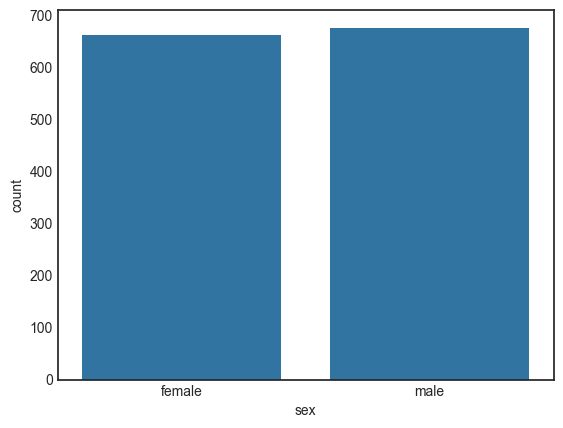

In [13]:
sns.countplot(x='sex', data=insurancedf)

In [14]:
# insurancedf.info()

In [15]:
categorical_columns = ['sex', 'smoker', 'region']
df_encode = pd.get_dummies(data = insurancedf, prefix = 'OHE', prefix_sep='_', columns = categorical_columns, dtype='int8')

In [16]:
df_encode.head()

,age,bmi,children,charges,OHE_female,OHE_male,OHE_no,OHE_yes,OHE_northeast,OHE_northwest,OHE_southeast,OHE_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [17]:
from sklearn.model_selection import train_test_split
X = df_encode.drop('charges',axis=1)
y = np.log(df_encode['charges'])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=23)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train) 

# sk_theta = [lin_reg.intercept_]+list(lin_reg.coef_)
# parameter_df = parameter_df.join(pd.Series(sk_theta, name='Sklearn_theta'))
# parameter_df

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train performance
print("Train R²:", r2_score(y_train, y_train_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))

# Test performance
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Train R²: 0.7623624821410289
Train RMSE: 0.4467246955421794
Train MAE: 0.28300350464187063
Test R²: 0.7767840303618613
Test RMSE: 0.43550241124377725
Test MAE: 0.28128559871914477


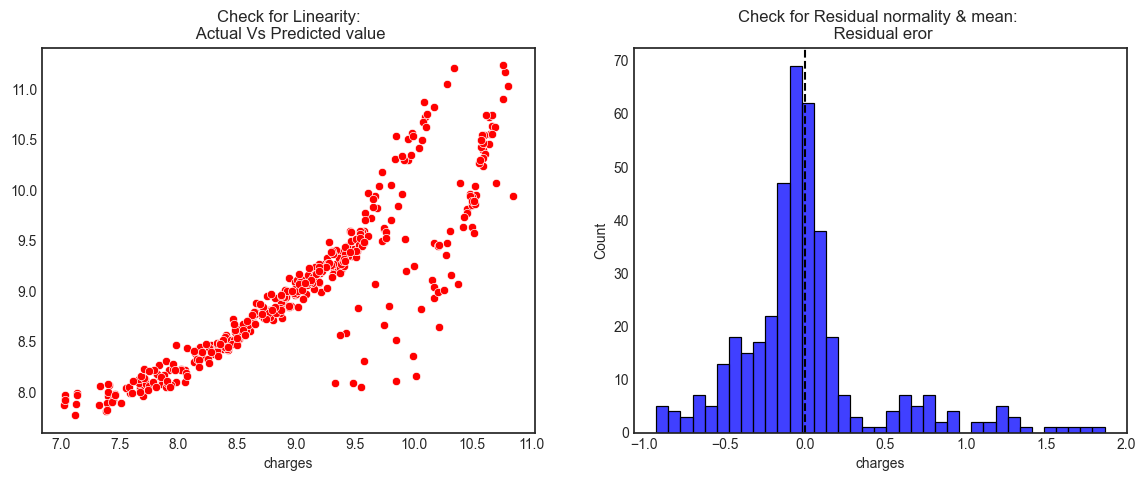

In [21]:
f = plt.figure(figsize=(14,5))
ax = f.add_subplot(121)
sns.scatterplot(x= y_test, y=y_test_pred, ax=ax, color='r')
ax.set_title('Check for Linearity:\n Actual Vs Predicted value')

# Check for Residual normality & mean
ax = f.add_subplot(122)
sns.histplot((y_test - y_test_pred),ax=ax,color='b')
ax.axvline((y_test - y_test_pred).mean(),color='k',linestyle='--')
ax.set_title('Check for Residual normality & mean: \n Residual eror');

Text(0.5, 1.0, 'Check for Homoscedasticity: \nResidual Vs Predicted')

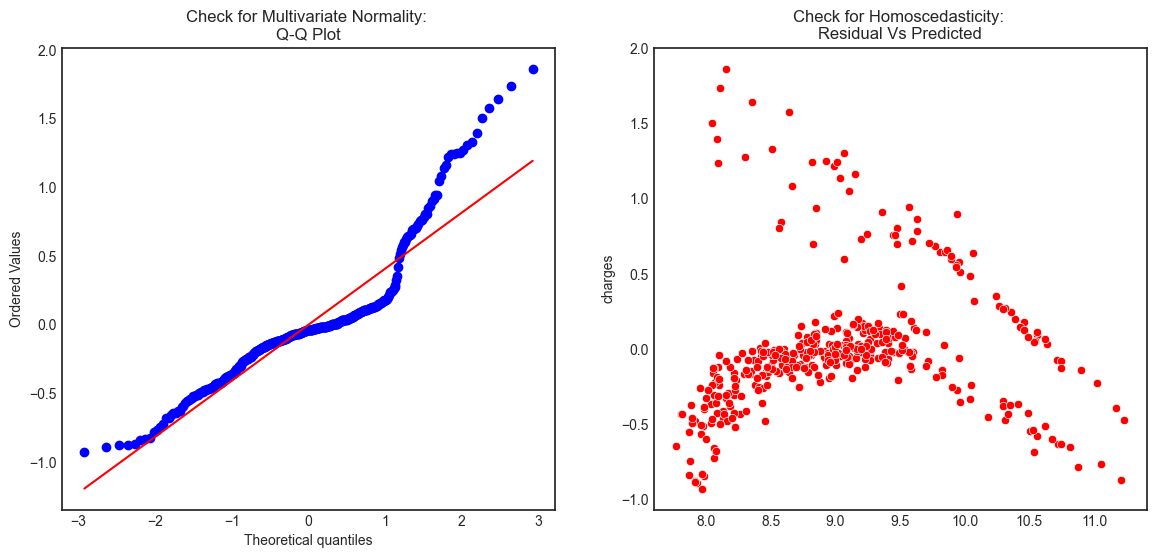

In [22]:
f,ax = plt.subplots(1,2,figsize=(14,6))
import scipy as sp

_,(_,_,r)= sp.stats.probplot((y_test - y_test_pred), fit=True, plot=ax[0])
ax[0].set_title('Check for Multivariate Normality: \nQ-Q Plot')

#Check for Homoscedasticity
sns.scatterplot(y = (y_test - y_test_pred), x= y_test_pred, ax = ax[1], color='r') 
ax[1].set_title('Check for Homoscedasticity: \nResidual Vs Predicted')

In [23]:
def residuals(model, X_test, y_test):
    y_pred = model.predict(X_test)
    df_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    df_results['Residuals'] = abs(df_results['Actual']) - abs(df_results['Predicted'])
    return df_results

In [24]:
def homoscedasticity_assumption(model, X_test, y_test):
    
    df_results = residuals(model, X_test, y_test)
    
    fig = plt.figure(figsize=(6,6), dpi=80)
    sns.regplot(x='Predicted', y='Residuals', data=df_results, lowess=True,
                color='#0055ff', line_kws={'color':'#ff7000','ls':'--','lw':2.5})
    plt.axhline(y=0, color='#23bf00', lw=1)
    plt.title('Residuals vs. Predicted Values', fontsize=15)
    plt.xlabel('Predicted Values', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)    
    plt.show()

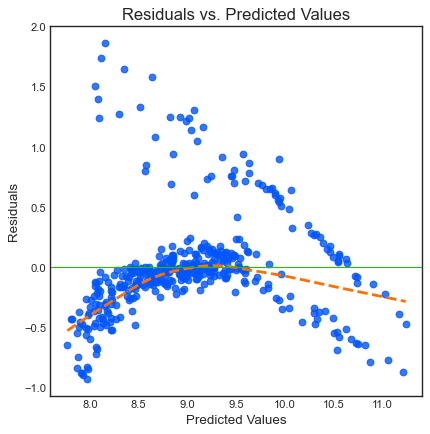

In [25]:
# The orange line is meant to be on the green line
homoscedasticity_assumption(model, X_test, y_test)

In [33]:
# To detect VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = df_encode.columns
vif_data["VIF"] = [variance_inflation_factor(df_encode.values, i) for i in range(len(df_encode.columns))]

# VIF = 1/(1- R_square_sk)
print(vif_data)

          feature       VIF
0             age  1.373348
1             bmi  1.223757
2        children  1.013005
3         charges  4.014662
4      OHE_female       inf
5        OHE_male       inf
6          OHE_no       inf
7         OHE_yes       inf
8   OHE_northeast       inf
9   OHE_northwest       inf
10  OHE_southeast       inf
11  OHE_southwest       inf


C:\Users\Kolade\AppData\Roaming\Python\Python312\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
# In our model the actual vs predicted plot is curve so linear assumption fails
# The residual mean is zero and residual error plot right skewed
# Q-Q plot shows as value log value greater than 1.5 trends to increase
# The plot is exhibit heteroscedastic, error will insease after certian point.
# Variance inflation factor value is less than 5, so no multicollearity.

In [ ]:
# Regularization: Ridge, Lasso, Elastic Net



### Linear Regression with a vahicle DataFrame

In [26]:
car_df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


selling Price is the independent variable

In [27]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [28]:
car_df.shape

(4340, 8)

In [29]:
car_df2 = pd.read_csv("car data.csv")
car_df2.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [30]:
car_df2.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [31]:
car_df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [32]:
# Converted the year column to age for better operating

current_year = datetime.now().year

car_df["age"] = current_year - car_df["year"]

In [33]:
car_df.drop('year', axis=1, inplace=True)
car_df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,age
0,Maruti 800 AC,60000,70000,Petrol,Individual,Manual,First Owner,18
1,Maruti Wagon R LXI Minor,135000,50000,Petrol,Individual,Manual,First Owner,18
2,Hyundai Verna 1.6 SX,600000,100000,Diesel,Individual,Manual,First Owner,13
3,Datsun RediGO T Option,250000,46000,Petrol,Individual,Manual,First Owner,8
4,Honda Amaze VX i-DTEC,450000,141000,Diesel,Individual,Manual,Second Owner,11


In [34]:
car_df_cop = car_df.copy()

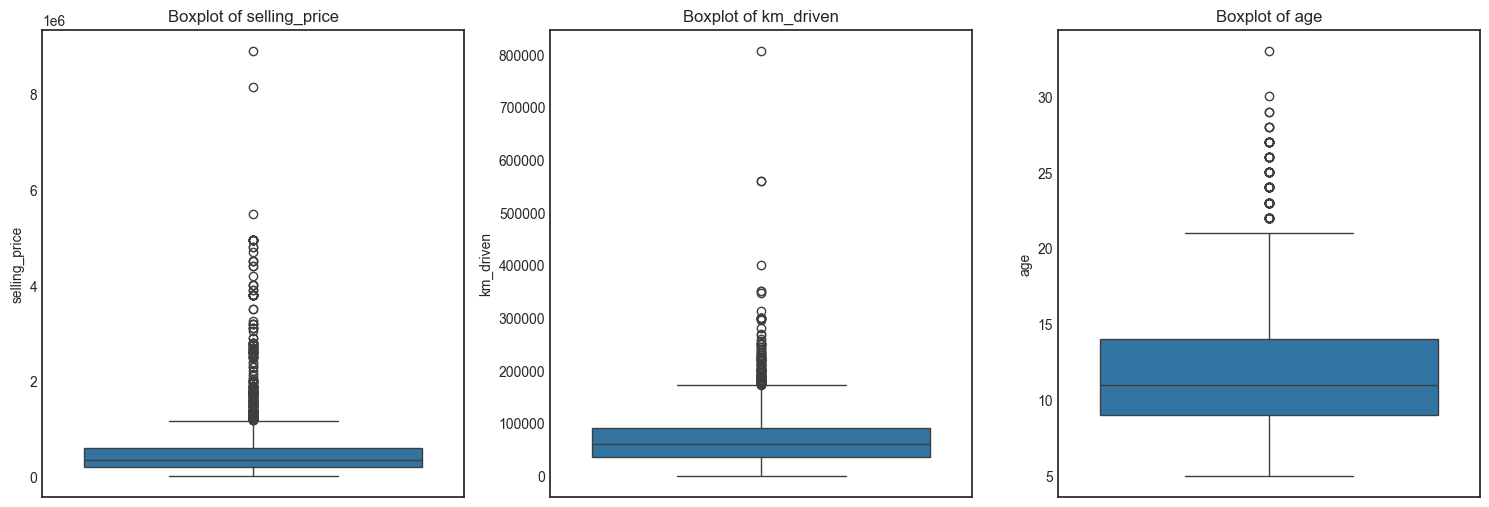

In [35]:
# Box plot of numerical variables against count against
numeric_cols = car_df.select_dtypes(include="number").columns
n = len(numeric_cols)

rows = (n // 3) + 1
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=car_df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [36]:
# Finding outliers

# outliers_indexes = []
# target = 'Selling_Price'

# for col in df.select_dtypes(include='object').columns:
#     for cat in df[col].unique():
#         df1 = df[df[col] == cat]
#         q1 = df1[target].quantile(0.25)
#         q3 = df1[target].quantile(0.75)
#         iqr = q3-q1
#         maximum = q3 + (1.5 * iqr)
#         minimum = q1 - (1.5 * iqr)
#         outlier_samples = df1[(df1[target] < minimum) | (df1[target] > maximum)]
#         outliers_indexes.extend(outlier_samples.index.tolist())
        
        
# for col in df.select_dtypes(exclude='object').columns:
#     q1 = df[col].quantile(0.25)
#     q3 = df[col].quantile(0.75)
#     iqr = q3-q1
#     maximum = q3 + (1.5 * iqr)
#     minimum = q1 - (1.5 * iqr)
#     outlier_samples = df[(df[col] < minimum) | (df[col] > maximum)]
#     outliers_indexes.extend(outlier_samples.index.tolist())
    
# outliers_indexes = list(set(outliers_indexes))
# print('{} outliers were identified, whose indices are:\n\n{}'.format(len(outliers_indexes), outliers_indexes))

In [37]:
me = car_df[car_df.duplicated()]
me
# car_df.info()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,age
13,Maruti 800 AC,60000,70000,Petrol,Individual,Manual,First Owner,18
14,Maruti Wagon R LXI Minor,135000,50000,Petrol,Individual,Manual,First Owner,18
15,Hyundai Verna 1.6 SX,600000,100000,Diesel,Individual,Manual,First Owner,13
16,Datsun RediGO T Option,250000,46000,Petrol,Individual,Manual,First Owner,8
17,Honda Amaze VX i-DTEC,450000,141000,Diesel,Individual,Manual,Second Owner,11
...,...,...,...,...,...,...,...,...
4307,Mahindra Xylo H4,599000,15000,Diesel,Individual,Manual,Third Owner,6
4308,Maruti Alto 800 LXI,200000,35000,Petrol,Individual,Manual,First Owner,7
4309,Datsun GO Plus T,350000,10171,Petrol,Dealer,Manual,First Owner,8
4310,Renault Duster 110PS Diesel RxL,465000,41123,Diesel,Dealer,Manual,First Owner,10


In [38]:
# We can leave the duplicates since there are be different owners with same price of car

In [39]:
car_df['owner'].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

In [40]:
len(car_df["name"].unique())

1491

## EDA

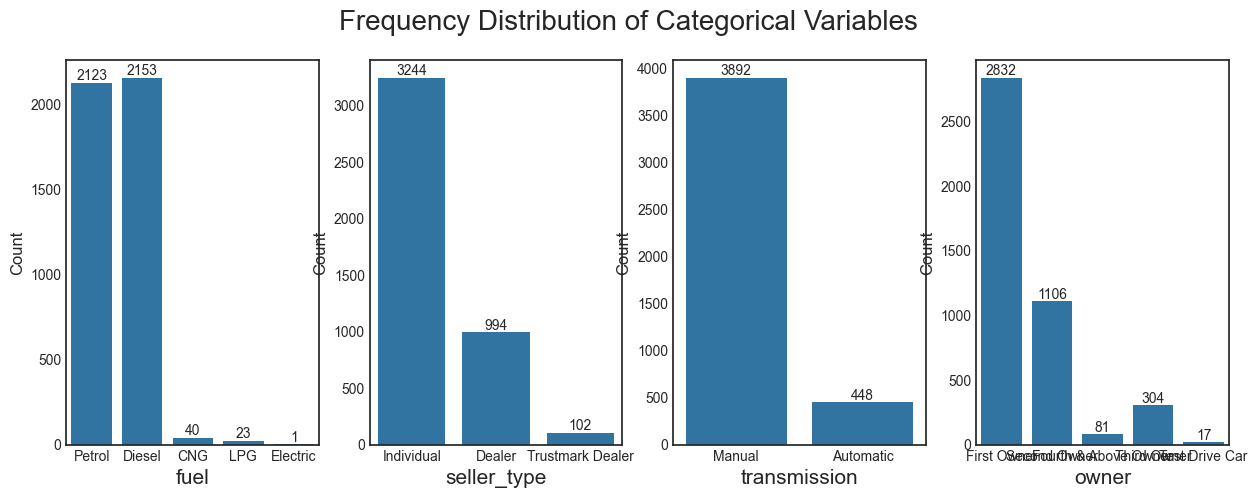

In [41]:
categoryCols = ['fuel', 'seller_type', 'transmission', 'owner']
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15,5), dpi=100)
# colors = ['#0055ff', '#ff7000', '#23bf00',]
# CustomPalette = sns.set_palette(sns.color_palette(colors))

for i in range(len(categoryCols)):
    graph = sns.countplot(x=categoryCols[i], data=car_df, ax=ax[i])
    ax[i].set_xlabel(categoryCols[i], fontsize=15)
    ax[i].set_ylabel('Count', fontsize=12)
    for cont in graph.containers:
        graph.bar_label(cont)

plt.suptitle('Frequency Distribution of Categorical Variables', fontsize=20) 
# plt.tight_layout()
plt.show()

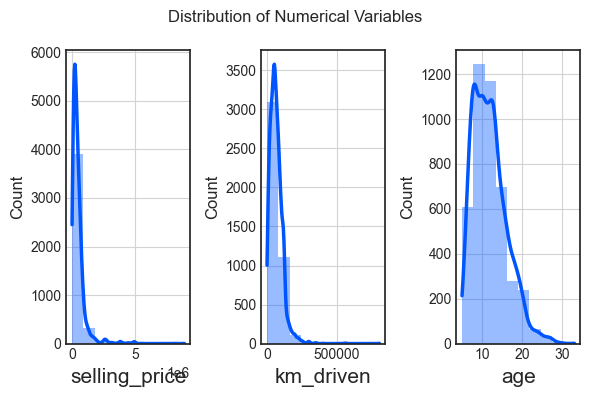

In [42]:
# histogram of numerical variable for skewness
numcols = ['selling_price', 'km_driven', 'age']
# fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5), dpi=100)

# for i in range(len(numcols)):
#     graph = sns.histplot(data=car_df, x = numcols[i], kde=True,
#             edgecolor='none', alpha=0.4)
# , ax=ax[row,col], line_kws={'lw': 2.5}

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6,4))
c = '#0055ff'

for i in range(len(numcols)):
    row = i//3
    col = i%3
    values, bin_edges = np.histogram(car_df[numcols[i]])                
    graph = sns.histplot(data=car_df, x=numcols[i], bins=bin_edges, kde=True, ax=ax[i],
                         edgecolor='none', color=c, alpha=0.4, line_kws={'lw': 2.5})
    ax[i].set_xlabel(numcols[i], fontsize=15)
    ax[i].set_ylabel('Count', fontsize=12)
    ax[i].grid(color='lightgrey')
plt.suptitle('Distribution of Numerical Variables') 
plt.tight_layout()   
plt.show()

In [43]:
car_df['log_age'] = np.log(car_df['age'])
car_df['log_kmdriven'] = np.log(car_df['km_driven'])
car_df = car_df.drop(['age', 'km_driven'], axis=1)

In [44]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

car_df = pd.get_dummies(car_df, columns=cat_cols, dtype=int)
car_df.head()

,name,selling_price,log_age,log_kmdriven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,60000,2.890372,11.156251,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
1,Maruti Wagon R LXI Minor,135000,2.890372,10.819778,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
2,Hyundai Verna 1.6 SX,600000,2.564949,11.512925,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0
3,Datsun RediGO T Option,250000,2.079442,10.736397,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
4,Honda Amaze VX i-DTEC,450000,2.397895,11.856515,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0


In [45]:
# Binary encoding for name
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

# encoder = ce.BinaryEncoder(cols=['name'])
# car_df = encoder.fit_transform(car_df)

ohe = LabelEncoder()
car_df['name_encoded'] = ohe.fit_transform(car_df['name'])

In [46]:
car_df.head()
car_df = car_df.drop('name', axis=1)

In [47]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   selling_price                 4340 non-null   int64  
 1   log_age                       4340 non-null   float64
 2   log_kmdriven                  4340 non-null   float64
 3   fuel_CNG                      4340 non-null   int64  
 4   fuel_Diesel                   4340 non-null   int64  
 5   fuel_Electric                 4340 non-null   int64  
 6   fuel_LPG                      4340 non-null   int64  
 7   fuel_Petrol                   4340 non-null   int64  
 8   seller_type_Dealer            4340 non-null   int64  
 9   seller_type_Individual        4340 non-null   int64  
 10  seller_type_Trustmark Dealer  4340 non-null   int64  
 11  transmission_Automatic        4340 non-null   int64  
 12  transmission_Manual           4340 non-null   int64  
 13  own

In [48]:
x_data = car_df.drop('selling_price', axis=1)
y_data = np.log(car_df['selling_price'])

In [49]:
x_train,x_test,y_train,y_test = train_test_split(x_data, y_data, test_size=0.25, random_state=42)

In [50]:
print('X_train shape: ', x_train.shape)
print('X_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ',y_test.shape)

X_train shape:  (3255, 18)
X_test shape:  (1085, 18)
y_train shape:  (3255,)
y_test shape:  (1085,)


In [51]:
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [52]:
linear_reg = LinearRegression()
linear_reg.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
def model_evaluation(x_test_scaled, y_test, model_name):
    y_pred = linear_reg.predict(x_test_scaled)
    
    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)
    
    return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index=['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns=[model_name])

In [54]:
model_evaluation(x_train_scaled, y_train, 'Linear Reg.')

,Linear Reg.
MAE,0.367456
MSE,0.221486
RMSE,0.470623
R2-Score,0.686241


In [55]:
model_evaluation(x_test_scaled, y_test, 'Linear Reg.')

,Linear Reg.
MAE,0.361534
MSE,0.223384
RMSE,0.472635
R2-Score,0.680155


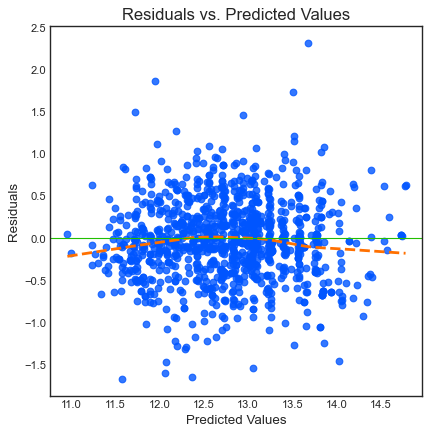

In [56]:
homoscedasticity_assumption(linear_reg, x_test_scaled, y_test)

In [57]:
# Doesn't seem to be overfitting, the training model accuracy is close to the testing accuracy
# Lets see random forest regressor

In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
y_pred = model.predict(x_test_scaled)
    
MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2_Score = metrics.r2_score(y_test, y_pred)
print(MAE)
print(MSE)
print(RMSE)
print(R2_Score)

0.2549294999181987
0.12575919968327276
0.35462543575337735
0.8199356219663045


In [44]:
# When cross validation is carried out with linear regression

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_validate

linearReg_cv = LinearRegression()
scaled = StandardScaler()
pipeline = make_pipeline(StandardScaler(), LinearRegression())

kf = KFold(n_splits = 5, shuffle = True, random_state = 0)

scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2']
scoring_result = cross_validate(pipeline, x_data, y_data, cv = kf, return_train_score = True, scoring = scoring)

MAE_mean = (-scoring_result['test_neg_mean_absolute_error']).mean()
MAE_std = (-scoring_result['test_neg_mean_absolute_error']).std()
MSE_mean = (-scoring_result['test_neg_mean_squared_error']).mean()
MSE_std = (-scoring_result['test_neg_mean_squared_error']).std()
RMSE_mean = (-scoring_result['test_neg_root_mean_squared_error']).mean()
RMSE_std = (-scoring_result['test_neg_root_mean_squared_error']).std()
R2_Score_mean = scoring_result['test_r2'].mean()
R2_Score_std = scoring_result['test_r2'].std()

pd.DataFrame({'Mean': [MAE_mean, MSE_mean, RMSE_mean, R2_Score_mean], 'Std': [MAE_std, MSE_std, RMSE_std, R2_Score_std]},
             index=['MAE', 'MSE', 'RMSE' ,'R2-Score'])

,Mean,Std
MAE,0.367446,0.003462
MSE,0.223442,0.007485
RMSE,0.472630,0.007915
R2-Score,0.681764,0.016496


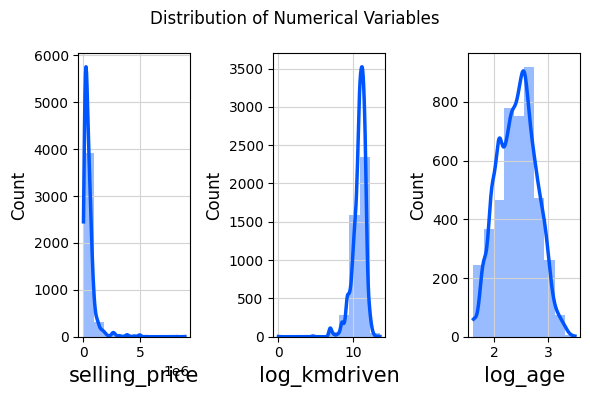

In [45]:
# ['selling_price', 'km_driven', 'age']

numcols = ['selling_price', 'log_kmdriven', 'log_age']

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6,4))
c = '#0055ff'

for i in range(len(numcols)):
    row = i//3
    col = i%3
    values, bin_edges = np.histogram(car_df[numcols[i]])                
    graph = sns.histplot(data=car_df, x=numcols[i], bins=bin_edges, kde=True, ax=ax[i],
                         edgecolor='none', color=c, alpha=0.4, line_kws={'lw': 2.5})
    ax[i].set_xlabel(numcols[i], fontsize=15)
    ax[i].set_ylabel('Count', fontsize=12)
    ax[i].grid(color='lightgrey')
plt.suptitle('Distribution of Numerical Variables') 
plt.tight_layout()   
plt.show()

In [58]:
car_df_cop.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,age
0,Maruti 800 AC,60000,70000,Petrol,Individual,Manual,First Owner,18
1,Maruti Wagon R LXI Minor,135000,50000,Petrol,Individual,Manual,First Owner,18
2,Hyundai Verna 1.6 SX,600000,100000,Diesel,Individual,Manual,First Owner,13
3,Datsun RediGO T Option,250000,46000,Petrol,Individual,Manual,First Owner,8
4,Honda Amaze VX i-DTEC,450000,141000,Diesel,Individual,Manual,Second Owner,11


In [59]:
car_df_transformed = car_df_cop.copy()

### Boxcox transformation for numerical columns to make it normal.

In [60]:
from scipy.stats import boxcox

lambdas = {}

for col in car_df_cop.select_dtypes(include = np.number).columns:
    transformed, lam = boxcox(car_df_cop[col])
    car_df_transformed[col] = transformed
    lambdas[col] = lam

print("Lambda Values:", lambdas)

Lambda Values: {'selling_price': np.float64(-0.021777659270727254), 'km_driven': np.float64(0.4216621881834263), 'age': np.float64(-0.02349673603933881)}


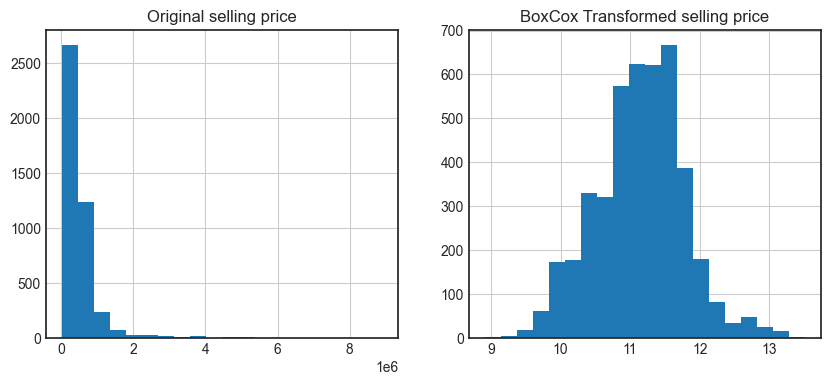

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

car_df_cop["selling_price"].hist(ax=axes[0], bins=20)
axes[0].set_title("Original selling price")

car_df_transformed["selling_price"].hist(ax=axes[1], bins=20)
axes[1].set_title("BoxCox Transformed selling price")

plt.show()

In [62]:
# comparison = pd.concat(
#     [car_df_cop.select_dtypes(include=[np.number]), car_df_transformed], 
#     axis=1, 
#     keys=["Original", "BoxCox"]
# )

# print(comparison)

In [63]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

car_df_transformed = pd.get_dummies(car_df_transformed, columns=cat_cols, dtype=int)
car_df_transformed.head()

,name,selling_price,km_driven,age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,9.783302,259.464810,2.794408,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
1,Maruti Wagon R LXI Minor,10.415855,224.831043,2.794408,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
2,Hyundai Verna 1.6 SX,11.550623,301.959496,2.489187,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0
3,Datsun RediGO T Option,10.889088,216.981652,2.029458,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
4,Honda Amaze VX i-DTEC,11.334630,349.404542,2.331594,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0


In [64]:
from sklearn.preprocessing import LabelEncoder

ohe = LabelEncoder()
car_df_transformed['name_encoded'] = ohe.fit_transform(car_df_transformed['name'])

In [65]:
car_df_transformed = car_df_transformed.drop('name', axis=1)

In [66]:
x_data = car_df_transformed.drop('selling_price', axis=1)
y_data = car_df_transformed['selling_price']

### Polynomial regression
This is used mostly when there is a case of over fitting and also used to model non-linear trends like when the price depends on 3 or more variables.

In [67]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(x_data)
X_poly = pd.DataFrame(X_poly, columns=poly_features.get_feature_names_out(x_data.columns))
X_poly.head(5)

,km_driven,age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,...,owner_Second Owner^2,owner_Second Owner owner_Test Drive Car,owner_Second Owner owner_Third Owner,owner_Second Owner name_encoded,owner_Test Drive Car^2,owner_Test Drive Car owner_Third Owner,owner_Test Drive Car name_encoded,owner_Third Owner^2,owner_Third Owner name_encoded,name_encoded^2
0,259.464810,2.794408,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,600625.0
1,224.831043,2.794408,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1083681.0
2,301.959496,2.489187,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,255025.0
3,216.981652,2.029458,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13924.0
4,349.404542,2.331594,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,279.0,0.0,0.0,0.0,0.0,0.0,77841.0


In [68]:
x_train,x_test,y_train,y_test = train_test_split(X_poly, y_data, test_size=0.25, random_state=0)

In [69]:
print('X_train shape: ', x_train.shape)
print('X_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ',y_test.shape)

X_train shape:  (3255, 189)
X_test shape:  (1085, 189)
y_train shape:  (3255,)
y_test shape:  (1085,)


In [70]:
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [77]:
y_test[10:20]

1116    10.718446
3915    11.741644
3859    11.581162
142     10.889088
2070    10.718446
2743    11.633114
2490    11.245807
3080    11.245807
1501    10.561280
1831    11.587120
Name: selling_price, dtype: float64

In [71]:
linear_reg = LinearRegression()
linear_reg.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
# def model_evaluation(x_test, y_test, model_name):
#     # y_pred = model.predict(X_test)
    
#     MAE = metrics.mean_absolute_error(y_test, y_pred)
#     MSE = metrics.mean_squared_error(y_test, y_pred)
#     RMSE = np.sqrt(MSE)
#     R2_Score = metrics.r2_score(y_test, y_pred)
    
#     return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index=['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns=[model_name])

In [73]:
model_evaluation(x_test_scaled, y_test, 'Polynomial Reg.')

,Polynomial Reg.
MAE,0.270648
MSE,0.127143
RMSE,0.356572
R2-Score,0.689626


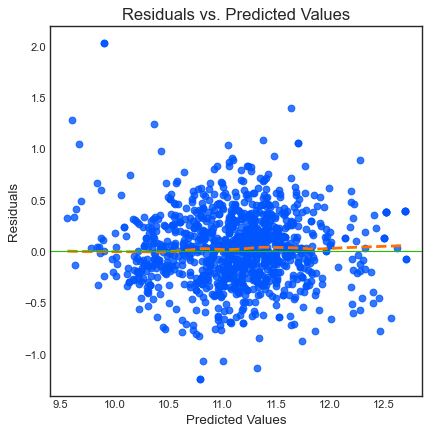

In [74]:
homoscedasticity_assumption(linear_reg, x_test_scaled, y_test)

In [92]:
# It is seen that the linear regression model is not really good for the dataset. Its predicting close, but could still capture variance better. Doesn't 
# really understand the underlying data patterns

### Regularization

In [121]:
x_train,x_test,y_train,y_test = train_test_split(x_data, y_data, test_size=0.25, random_state=0)

In [122]:
print('X_train shape: ', x_train.shape)
print('X_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ',y_test.shape)

X_train shape:  (3255, 18)
X_test shape:  (1085, 18)
y_train shape:  (3255,)
y_test shape:  (1085,)


In [123]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [124]:
alphas = 10**np.linspace(10,-3,100)*0.5

ridge_cv_model = RidgeCV(alphas = alphas, cv = 3, scoring = 'neg_mean_squared_error')                        
ridge_cv_model.fit(x_train, y_train)

,alphas,array([5.0000...00000000e-04])
,fit_intercept,True
,scoring,'neg_mean_squared_error'
,cv,3
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [125]:
ridge_cv_model.alpha_

np.float64(14.575265314125849)

In [127]:
def model_evaluation2(x_test, y_test, model_name):
    y_pred = ridge_cv_model.predict(x_test)
    
    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)
    
    return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index=['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns=[model_name])

In [128]:
model_evaluation2(x_test, y_test, 'Ridge Reg. Test')

,Ridge Reg. Test
MAE,0.278703
MSE,0.128218
RMSE,0.358076
R2-Score,0.687002


### Lasso

In [129]:
lasso_cv_model = LassoCV(eps=0.01, alphas=100, max_iter=10000, cv=3)

In [130]:
lasso_cv_model.fit(x_train_scaled, y_train)

,eps,0.01
,n_alphas,'deprecated'
,alphas,100
,fit_intercept,True
,precompute,'auto'
,max_iter,10000
,tol,0.0001
,copy_X,True
,cv,3
,verbose,False
,n_jobs,None


In [131]:
def model_evaluation2(x_test, y_test, model_name):
    y_pred = lasso_cv_model.predict(x_test)
    
    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)
    
    return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index=['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns=[model_name])
model_evaluation2(x_test_scaled, y_test, 'Lasso Reg. Test')

,Lasso Reg. Test
MAE,0.270796
MSE,0.125939
RMSE,0.354879
R2-Score,0.692566


### Elastic Net

In [132]:
elastic_cv_model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, .995, .998, 1], eps=0.01, alphas=100, cv=3, max_iter=100000)

In [133]:
elastic_cv_model.fit(x_train_scaled, y_train)

,l1_ratio,"[0.1, 0.5, ...]"
,eps,0.01
,n_alphas,'deprecated'
,alphas,100
,fit_intercept,True
,precompute,'auto'
,max_iter,100000
,tol,0.0001
,cv,3
,copy_X,True
,verbose,0


In [137]:
def model_evaluation2(x_test, y_test, model_name):
    y_pred = elastic_cv_model.predict(x_test)
    
    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)
    
    return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index=['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns=[model_name])
model_evaluation2(x_test_scaled, y_test, 'Elastic Net Test')

,Elastic Net Test
MAE,0.271084
MSE,0.126017
RMSE,0.354989
R2-Score,0.692375


In [138]:
elastic_cv_model.l1_ratio_

np.float64(0.5)

In [139]:
elastic_cv_model.alpha_

np.float64(0.010151289610936977)

In [ ]:
# They only make sense in models that have coefficients (like linear regression, logistic regression, generalized linear models
# Tree based models don’t have coefficients in the same sense — they split the data into regions.
# Regularization for trees works differently:
# Tree depth (max_depth)
# Min samples per split/leaf
# Max features per split
# Number of trees (in ensemble methods)
# Learning rate (in boosting)
# These hyperparameters control complexity instead of penalties like Ridge/Lasso.
# So you can’t apply Ridge or Lasso directly to a Random Forest or Decision Tree.